In [ ]:
Built a CNN-based chest X-ray Pneumonia Detection system leveraging transfer learning and a Kaggle-sourced dataset for automated image classification.

In [ ]:
"""
AURA-Net: Attention-driven, Uncertainty-aware, Radiological Assessment Network
================================================================================
A production-grade multi-task architecture for the Kaggle "Chest X-Ray Images
(Pneumonia)" dataset that goes beyond binary classification.

Architectural mandates implemented:
  1. Test-Time MC Dropout           -> epistemic uncertainty + auto-triage flagging
  2. Custom CBAM attention          -> injected at all 4 DenseNet121 scale transitions
  3. Multi-task heads               -> pneumonia / bacterial-vs-viral / severity index
  4. Focal Loss (binary + multiclass) -> hard-example mining + class imbalance handling

Requirements: torch>=1.12, torchvision>=0.13, pillow

Author note on the severity label:
  The public Kaggle dataset has NO ground-truth severity annotation. Rather than
  inventing one silently, this script computes a documented weak-supervision
  PSEUDO-LABEL (see `compute_severity_pseudo_label`) from lung-ROI opacity
  density. In a real deployment you would replace this function with either
  (a) radiologist-graded severity scores, or (b) a segmentation-derived
  consolidation-area ratio from a trained lung/opacity segmentation model.
  Everything downstream (loss masking, head design, inference) is written to
  be agnostic to where the severity label actually comes from.
"""

import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image


# ============================================================================
# SECTION 0: Reproducibility & device utilities
# ============================================================================

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================================
# SECTION 1: Custom Spatial & Channel Attention (CBAM)
# ============================================================================

class ChannelAttention(nn.Module):
    """Squeeze-and-excite style channel attention using both avg and max pooled
    descriptors, so the module attends to *what* is diagnostically relevant
    (lung opacity texture channels) rather than treating all feature maps
    equally."""

    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, reduced, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced, channels, kernel_size=1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        gate = self.sigmoid(avg_out + max_out)
        return x * gate


class SpatialAttention(nn.Module):
    """Spatial attention that highlights *where* in the image (e.g. focal lung
    opacities) matters, while suppressing constant background structures like
    ribs and clavicles that carry little diagnostic signal but high contrast."""

    def __init__(self, kernel_size: int = 7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        gate = self.sigmoid(self.conv(concat))
        return x * gate


class CBAM(nn.Module):
    """Sequential channel -> spatial attention block (Woo et al., 2018),
    reused at every DenseNet121 dense-block boundary so attention operates
    across four different receptive-field scales."""

    def __init__(self, channels: int, reduction: int = 16, kernel_size: int = 7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


# ============================================================================
# SECTION 2: Attention-augmented DenseNet121 backbone
# ============================================================================

class AttentionDenseNet121(nn.Module):
    """DenseNet121 with CBAM inserted after every dense block. The final
    Dropout is deliberately kept as a standalone `nn.Dropout` module (never
    fused/replaced) so it can later be toggled into train-mode at inference
    time for Monte Carlo Dropout without touching BatchNorm statistics.

    Channel progression (standard DenseNet121, growth_rate=32,
    block_config=(6, 12, 24, 16)):
        stem            -> 64 channels
        denseblock1     -> 256 channels   (CBAM #1)
        transition1     -> 128 channels
        denseblock2     -> 512 channels   (CBAM #2)
        transition2     -> 256 channels
        denseblock3     -> 1024 channels  (CBAM #3)
        transition3     -> 512 channels
        denseblock4     -> 1024 channels  (CBAM #4)
        norm5           -> 1024 channels (final feature map)
    """

    def __init__(self, pretrained: bool = True, dropout_p: float = 0.3):
        super().__init__()
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        densenet = models.densenet121(weights=weights)
        self.features = densenet.features

        self.cbam1 = CBAM(256)
        self.cbam2 = CBAM(512)
        self.cbam3 = CBAM(1024)
        self.cbam4 = CBAM(1024)

        self.mc_dropout = nn.Dropout(p=dropout_p)
        self.out_channels = 1024

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features.conv0(x)
        x = self.features.norm0(x)
        x = self.features.relu0(x)
        x = self.features.pool0(x)

        x = self.features.denseblock1(x)
        x = self.cbam1(x)
        x = self.features.transition1(x)

        x = self.features.denseblock2(x)
        x = self.cbam2(x)
        x = self.features.transition2(x)

        x = self.features.denseblock3(x)
        x = self.cbam3(x)
        x = self.features.transition3(x)

        x = self.features.denseblock4(x)
        x = self.cbam4(x)
        x = self.features.norm5(x)
        x = F.relu(x, inplace=True)
        x = self.mc_dropout(x)
        return x  # (B, 1024, H', W')


# ============================================================================
# SECTION 3: Multi-task head
# ============================================================================

class MultiTaskPneumoniaNet(nn.Module):
    """Shared attention-backbone trunk feeding three task-specific heads:
        - pneumonia_logit : (B,)   binary presence logit
        - etiology_logit  : (B,3)  {0: none/normal, 1: bacterial, 2: viral}
        - severity         : (B,)   continuous index in [0, 1]
    """

    def __init__(self, pretrained: bool = True, dropout_p: float = 0.3):
        super().__init__()
        self.backbone = AttentionDenseNet121(pretrained=pretrained, dropout_p=dropout_p)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.shared_fc = nn.Sequential(
            nn.Linear(self.backbone.out_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )

        self.pneumonia_head = nn.Linear(256, 1)
        self.etiology_head = nn.Linear(256, 3)
        self.severity_head = nn.Sequential(nn.Linear(256, 1), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> dict:
        feat_map = self.backbone(x)
        pooled = self.global_pool(feat_map).flatten(1)
        shared = self.shared_fc(pooled)

        pneumonia_logit = self.pneumonia_head(shared).squeeze(-1)
        etiology_logit = self.etiology_head(shared)
        severity = self.severity_head(shared).squeeze(-1)

        return {
            "pneumonia_logit": pneumonia_logit,
            "etiology_logit": etiology_logit,
            "severity": severity,
        }


# ============================================================================
# SECTION 4: Focal Loss (binary + multiclass)
# ============================================================================

class BinaryFocalLoss(nn.Module):
    """Focal loss (Lin et al., 2017) for the pneumonia-presence head. Handles
    the ~3:1 pneumonia/normal imbalance in the Kaggle dataset and down-weights
    easy, already-confident examples so training focuses on hard cases."""

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = (1 - pt).clamp(min=1e-6) ** self.gamma
        alpha_weight = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        loss = alpha_weight * focal_weight * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


class MultiClassFocalLoss(nn.Module):
    """Focal loss for the 3-way etiology head. Supports an optional per-sample
    mask so that "normal" samples (which have no meaningful etiology label)
    can be excluded from the etiology loss entirely, rather than being forced
    into an arbitrary class."""

    def __init__(self, num_classes: int = 3, gamma: float = 2.0,
                 class_weights: torch.Tensor = None, reduction: str = "mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.num_classes = num_classes
        if class_weights is None:
            class_weights = torch.ones(num_classes)
        self.register_buffer("class_weights", class_weights)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor,
                mask: torch.Tensor = None) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()

        targets_one_hot = F.one_hot(targets, num_classes=logits.size(-1)).float()
        pt = (probs * targets_one_hot).sum(dim=-1).clamp(min=1e-6)
        log_pt = (log_probs * targets_one_hot).sum(dim=-1)

        alpha_t = self.class_weights.to(logits.device)[targets]
        focal_weight = alpha_t * (1 - pt) ** self.gamma
        loss = -focal_weight * log_pt

        if mask is not None:
            loss = loss * mask
            denom = mask.sum().clamp(min=1.0)
            if self.reduction == "mean":
                return loss.sum() / denom
            elif self.reduction == "sum":
                return loss.sum()
            return loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


class MultiTaskFocalLoss(nn.Module):
    """Combines all three task losses into a single weighted objective.
    The etiology loss is masked to pneumonia-positive samples only; the
    severity loss is applied to all samples (normal cases are expected to
    converge toward a severity target near 0)."""

    def __init__(self, pneumonia_weight: float = 1.0, etiology_weight: float = 0.5,
                 severity_weight: float = 0.5, focal_alpha: float = 0.25,
                 focal_gamma: float = 2.0):
        super().__init__()
        self.pneumonia_loss_fn = BinaryFocalLoss(alpha=focal_alpha, gamma=focal_gamma)
        self.etiology_loss_fn = MultiClassFocalLoss(num_classes=3, gamma=focal_gamma)
        self.severity_loss_fn = nn.MSELoss(reduction="none")

        self.w_pneumonia = pneumonia_weight
        self.w_etiology = etiology_weight
        self.w_severity = severity_weight

    def forward(self, outputs: dict, targets: dict) -> dict:
        pneumonia_target = targets["pneumonia_label"].float()
        etiology_target = targets["etiology_label"].long()
        severity_target = targets["severity_label"].float()

        loss_pneumonia = self.pneumonia_loss_fn(outputs["pneumonia_logit"], pneumonia_target)

        etiology_mask = (pneumonia_target == 1).float()
        loss_etiology = self.etiology_loss_fn(outputs["etiology_logit"], etiology_target, mask=etiology_mask)

        severity_raw = self.severity_loss_fn(outputs["severity"], severity_target)
        loss_severity = severity_raw.mean()

        total = (self.w_pneumonia * loss_pneumonia
                 + self.w_etiology * loss_etiology
                 + self.w_severity * loss_severity)

        return {
            "total_loss": total,
            "pneumonia_loss": loss_pneumonia.detach(),
            "etiology_loss": loss_etiology.detach(),
            "severity_loss": loss_severity.detach(),
        }


# ============================================================================
# SECTION 5: Dataset — filename parsing + severity pseudo-label
# ============================================================================

class ChestXrayFilenameParser:
    """The Kaggle Chest X-Ray Pneumonia dataset encodes etiology directly in
    filenames, e.g.:
        person1_bacteria_2.jpeg   -> pneumonia, bacterial
        person3_virus_15.jpeg     -> pneumonia, viral
        NORMAL2-IM-0588-0001.jpeg -> normal
    """

    @staticmethod
    def parse(filename: str):
        fname = filename.lower()
        if "bacteria" in fname:
            return 1, 1  # pneumonia=1, etiology=bacterial
        elif "virus" in fname:
            return 1, 2  # pneumonia=1, etiology=viral
        else:
            return 0, 0  # normal, etiology=none


def compute_severity_pseudo_label(raw_image_tensor: torch.Tensor, roi_fraction: float = 0.6) -> float:
    """Weak-supervision severity proxy (see module docstring for caveats).

    Heuristic: within a centered lung ROI, pixels brighter than
    (mean + 0.5*std) are treated as candidate consolidation/opacity regions.
    The fraction of such pixels is used as a severity proxy in [0, 1].

    This is NOT a clinically validated severity score. Replace with
    radiologist annotations or a segmentation-derived opacity-area ratio
    for real deployment.

    Args:
        raw_image_tensor: (C, H, W) tensor, values roughly in [0, 1], NOT
            ImageNet-normalized (normalization would distort the intensity
            heuristic).
    """
    gray = raw_image_tensor.mean(dim=0)
    h, w = gray.shape
    ch, cw = int(h * roi_fraction), int(w * roi_fraction)
    top, left = (h - ch) // 2, (w - cw) // 2
    roi = gray[top:top + ch, left:left + cw]

    mean_val = roi.mean()
    std_val = roi.std()
    threshold = mean_val + 0.5 * std_val

    opacity_mask = (roi > threshold).float()
    severity = opacity_mask.mean().clamp(0.0, 1.0)
    return float(severity.item())


class ChestXrayMultiTaskDataset(Dataset):
    """Reads images from disk paths, parses multi-task labels from filenames,
    and computes the severity pseudo-label on the fly."""

    def __init__(self, image_paths, image_size: int = 224, transform=None):
        self.image_paths = image_paths
        self.image_size = image_size
        self.normalize_transform = transform if transform is not None else self._default_transform(image_size)
        self.raw_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def _default_transform(self, image_size: int):
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> dict:
        path = self.image_paths[idx]
        filename = os.path.basename(path)
        image = Image.open(path).convert("RGB")

        image_tensor = self.normalize_transform(image)
        raw_tensor = self.raw_transform(image)

        pneumonia_label, etiology_label = ChestXrayFilenameParser.parse(filename)
        severity_label = compute_severity_pseudo_label(raw_tensor) if pneumonia_label == 1 else 0.0

        return {
            "image": image_tensor,
            "pneumonia_label": torch.tensor(pneumonia_label, dtype=torch.float32),
            "etiology_label": torch.tensor(etiology_label, dtype=torch.long),
            "severity_label": torch.tensor(severity_label, dtype=torch.float32),
            "filename": filename,
        }


def build_image_paths(root_dir: str, split: str = "train") -> list:
    """Expects the standard Kaggle layout:
        root_dir/
          train/{NORMAL,PNEUMONIA}/*.jpeg
          val/{NORMAL,PNEUMONIA}/*.jpeg
          test/{NORMAL,PNEUMONIA}/*.jpeg
    """
    paths = []
    for cls in ("NORMAL", "PNEUMONIA"):
        cls_dir = os.path.join(root_dir, split, cls)
        if os.path.isdir(cls_dir):
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith((".jpeg", ".jpg", ".png")):
                    paths.append(os.path.join(cls_dir, fname))
    return paths


# ============================================================================
# SECTION 6: Monte Carlo Dropout — epistemic uncertainty at inference
# ============================================================================

def enable_mc_dropout(model: nn.Module) -> None:
    """Switches only nn.Dropout modules into train() mode while leaving
    BatchNorm (and everything else) in eval() mode, so running statistics
    are not corrupted by test-time stochasticity."""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


@torch.no_grad()
def mc_dropout_inference(model: nn.Module, images: torch.Tensor, T: int = 30) -> dict:
    """Runs T stochastic forward passes with dropout active and aggregates
    mean / variance per task, giving an epistemic-uncertainty estimate
    usable for automatic low-confidence triage flagging.

    Returns a dict of tensors, each of shape (B,) except etiology which is
    (B, 3) for mean/var.
    """
    model.eval()
    enable_mc_dropout(model)

    pneumonia_samples, severity_samples, etiology_samples = [], [], []

    for _ in range(T):
        outputs = model(images)
        pneumonia_samples.append(torch.sigmoid(outputs["pneumonia_logit"]).unsqueeze(0))
        severity_samples.append(outputs["severity"].unsqueeze(0))
        etiology_samples.append(F.softmax(outputs["etiology_logit"], dim=-1).unsqueeze(0))

    pneumonia_samples = torch.cat(pneumonia_samples, dim=0)  # (T, B)
    severity_samples = torch.cat(severity_samples, dim=0)    # (T, B)
    etiology_samples = torch.cat(etiology_samples, dim=0)    # (T, B, 3)

    return {
        "pneumonia_prob_mean": pneumonia_samples.mean(dim=0),
        "pneumonia_prob_var": pneumonia_samples.var(dim=0, unbiased=False),
        "severity_mean": severity_samples.mean(dim=0),
        "severity_var": severity_samples.var(dim=0, unbiased=False),
        "etiology_prob_mean": etiology_samples.mean(dim=0),
        "etiology_prob_var": etiology_samples.var(dim=0, unbiased=False),
    }


def clinical_triage_report(mc_results: dict, pneumonia_threshold: float = 0.5,
                            uncertainty_threshold: float = 0.02) -> list:
    """Converts MC-dropout statistics into a per-sample structured report,
    auto-flagging cases whose epistemic variance exceeds `uncertainty_threshold`
    for mandatory radiologist review regardless of the point-estimate
    confidence."""
    etiology_names = ["none/normal", "bacterial", "viral"]
    batch_size = mc_results["pneumonia_prob_mean"].shape[0]

    reports = []
    for i in range(batch_size):
        pneumonia_prob = mc_results["pneumonia_prob_mean"][i].item()
        pneumonia_var = mc_results["pneumonia_prob_var"][i].item()
        severity = mc_results["severity_mean"][i].item()
        severity_var = mc_results["severity_var"][i].item()
        etiology_probs = mc_results["etiology_prob_mean"][i]
        etiology_idx = int(torch.argmax(etiology_probs).item())

        flagged = pneumonia_var > uncertainty_threshold
        prediction = "PNEUMONIA" if pneumonia_prob >= pneumonia_threshold else "NORMAL"

        reports.append({
            "prediction": prediction,
            "pneumonia_probability": round(pneumonia_prob, 4),
            "pneumonia_epistemic_variance": round(pneumonia_var, 6),
            "predicted_etiology": etiology_names[etiology_idx],
            "etiology_confidence": round(float(etiology_probs[etiology_idx].item()), 4),
            "severity_index": round(severity, 4),
            "severity_epistemic_variance": round(severity_var, 6),
            "flagged_for_radiologist_review": bool(flagged),
        })
    return reports


# ============================================================================
# SECTION 7: Training / validation loop utilities
# ============================================================================

def train_one_epoch(model: nn.Module, loader: DataLoader, loss_fn: nn.Module,
                     optimizer: torch.optim.Optimizer, device: torch.device) -> dict:
    model.train()
    running = {"total_loss": 0.0, "pneumonia_loss": 0.0, "etiology_loss": 0.0, "severity_loss": 0.0}
    n_batches = 0

    for batch in loader:
        images = batch["image"].to(device)
        targets = {
            "pneumonia_label": batch["pneumonia_label"].to(device),
            "etiology_label": batch["etiology_label"].to(device),
            "severity_label": batch["severity_label"].to(device),
        }

        optimizer.zero_grad()
        outputs = model(images)
        losses = loss_fn(outputs, targets)
        losses["total_loss"].backward()
        optimizer.step()

        for key in running:
            running[key] += losses[key].item()
        n_batches += 1

    return {key: value / max(n_batches, 1) for key, value in running.items()}


@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader, loss_fn: nn.Module, device: torch.device) -> dict:
    model.eval()
    running = {"total_loss": 0.0, "pneumonia_loss": 0.0, "etiology_loss": 0.0, "severity_loss": 0.0}
    n_batches = 0

    for batch in loader:
        images = batch["image"].to(device)
        targets = {
            "pneumonia_label": batch["pneumonia_label"].to(device),
            "etiology_label": batch["etiology_label"].to(device),
            "severity_label": batch["severity_label"].to(device),
        }
        outputs = model(images)
        losses = loss_fn(outputs, targets)

        for key in running:
            running[key] += losses[key].item()
        n_batches += 1

    return {key: value / max(n_batches, 1) for key, value in running.items()}


def train_model(root_dir: str, epochs: int = 10, batch_size: int = 16,
                 lr: float = 1e-4, pretrained: bool = True) -> nn.Module:
    """End-to-end training entry point against a real Kaggle-layout directory.
    Not executed automatically — call this yourself once you have the dataset
    downloaded, e.g.:

        model = train_model("/path/to/chest_xray", epochs=15)
    """
    device = get_device()
    set_seed(42)

    train_paths = build_image_paths(root_dir, split="train")
    val_paths = build_image_paths(root_dir, split="val")
    if len(val_paths) == 0:
        # Kaggle's official val split has only 16 images; fall back to test split
        # for a more meaningful validation signal if val/ is empty or missing.
        val_paths = build_image_paths(root_dir, split="test")

    train_dataset = ChestXrayMultiTaskDataset(train_paths)
    val_dataset = ChestXrayMultiTaskDataset(val_paths)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                               num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=4, pin_memory=True)

    model = MultiTaskPneumoniaNet(pretrained=pretrained).to(device)
    loss_fn = MultiTaskFocalLoss().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss = float("inf")
    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_metrics = validate(model, val_loader, loss_fn, device)
        scheduler.step()

        print(f"[Epoch {epoch}/{epochs}] "
              f"train_total={train_metrics['total_loss']:.4f} "
              f"val_total={val_metrics['total_loss']:.4f} "
              f"val_pneumonia={val_metrics['pneumonia_loss']:.4f} "
              f"val_etiology={val_metrics['etiology_loss']:.4f} "
              f"val_severity={val_metrics['severity_loss']:.4f}")

        if val_metrics["total_loss"] < best_val_loss:
            best_val_loss = val_metrics["total_loss"]
            torch.save(model.state_dict(), "aura_net_best.pt")

    return model


# ============================================================================
# SECTION 8: Synthetic end-to-end verification (no dataset required)
# ============================================================================

if __name__ == "__main__":
    set_seed(42)
    device = get_device()
    print(f"Running synthetic verification on device: {device}")

    batch_size = 8
    image_size = 224

    # --- synthetic filenames mimicking the real Kaggle naming convention ---
    synthetic_filenames = [
        "person1_bacteria_2.jpeg",
        "person3_virus_15.jpeg",
        "NORMAL2-IM-0588-0001.jpeg",
        "person7_bacteria_25.jpeg",
        "person9_virus_29.jpeg",
        "NORMAL2-IM-0601-0001.jpeg",
        "person12_bacteria_47.jpeg",
        "person15_virus_46.jpeg",
    ]
    assert len(synthetic_filenames) == batch_size

    pneumonia_labels, etiology_labels = [], []
    for fname in synthetic_filenames:
        p_label, e_label = ChestXrayFilenameParser.parse(fname)
        pneumonia_labels.append(p_label)
        etiology_labels.append(e_label)

    pneumonia_labels = torch.tensor(pneumonia_labels, dtype=torch.float32, device=device)
    etiology_labels = torch.tensor(etiology_labels, dtype=torch.long, device=device)

    # severity pseudo-labels: synthesized directly here (no real images available)
    severity_labels = torch.where(
        pneumonia_labels == 1,
        torch.rand(batch_size, device=device) * 0.6 + 0.2,  # pneumonia: 0.2-0.8
        torch.zeros(batch_size, device=device),
    )

    targets = {
        "pneumonia_label": pneumonia_labels,
        "etiology_label": etiology_labels,
        "severity_label": severity_labels,
    }

    # --- synthetic images (random tensors standing in for real X-rays) ---
    images = torch.randn(batch_size, 3, image_size, image_size, device=device)

    # pretrained=False so this verification never requires network access;
    # set pretrained=True when training against the real dataset with internet.
    model = MultiTaskPneumoniaNet(pretrained=False, dropout_p=0.3).to(device)

    print("\n--- Forward pass shape verification ---")
    outputs = model(images)
    for key, value in outputs.items():
        print(f"{key}: {tuple(value.shape)}")

    assert outputs["pneumonia_logit"].shape == (batch_size,)
    assert outputs["etiology_logit"].shape == (batch_size, 3)
    assert outputs["severity"].shape == (batch_size,)
    print("All output head shapes verified correctly.")

    print("\n--- Loss computation & backward pass verification ---")
    loss_fn = MultiTaskFocalLoss().to(device)
    losses = loss_fn(outputs, targets)
    for key, value in losses.items():
        print(f"{key}: {value.item():.6f}")

    losses["total_loss"].backward()
    grad_found = any(p.grad is not None and p.grad.abs().sum().item() > 0
                      for p in model.parameters() if p.requires_grad)
    assert grad_found, "No gradients propagated — architecture is disconnected somewhere."
    print("Gradients propagated successfully through all task heads.")

    print("\n--- Monte Carlo Dropout uncertainty inference ---")
    mc_results = mc_dropout_inference(model, images, T=10)
    for key, value in mc_results.items():
        print(f"{key}: {tuple(value.shape)}")

    print("\n--- Clinical triage report (synthetic) ---")
    reports = clinical_triage_report(mc_results, pneumonia_threshold=0.5, uncertainty_threshold=0.0005)
    for i, report in enumerate(reports):
        print(f"Sample {i} ({synthetic_filenames[i]}): {report}")

    print("\nSynthetic end-to-end verification completed with no errors.")

Running synthetic verification on device: cpu

--- Forward pass shape verification ---
pneumonia_logit: (8,)
etiology_logit: (8, 3)
severity: (8,)
All output head shapes verified correctly.

--- Loss computation & backward pass verification ---
total_loss: 0.387413
pneumonia_loss: 0.065534
etiology_loss: 0.550008
severity_loss: 0.093750
Gradients propagated successfully through all task heads.

--- Monte Carlo Dropout uncertainty inference ---
pneumonia_prob_mean: (8,)
pneumonia_prob_var: (8,)
severity_mean: (8,)
severity_var: (8,)
etiology_prob_mean: (8, 3)
etiology_prob_var: (8, 3)

--- Clinical triage report (synthetic) ---
Sample 0 (person1_bacteria_2.jpeg): {'prediction': 'PNEUMONIA', 'pneumonia_probability': 0.5043, 'pneumonia_epistemic_variance': 2e-06, 'predicted_etiology': 'none/normal', 'etiology_confidence': 0.34, 'severity_index': 0.5026, 'severity_epistemic_variance': 4e-06, 'flagged_for_radiologist_review': False}
Sample 1 (person3_virus_15.jpeg): {'prediction': 'PNEUMONI

In [4]:
!pip install -q kaggle

In [5]:
# ============================================================
# 1. Download Dataset
# ============================================================

import kagglehub
import os

path = kagglehub.dataset_download("nkifor/pneumonia-dataset")

print("Dataset downloaded to:")
print(path)

print("\nDataset contents:")
for item in os.listdir(path):
    print(" -", item)

100%|██████████| 1.07G/1.07G [00:11<00:00, 96.7MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/nkifor/pneumonia-dataset/versions/1

Dataset contents:
 - xraychest


In [6]:
import os

dataset_root = "/root/.cache/kagglehub/datasets/nkifor/pneumonia-dataset/versions/1/xraychest"

for root, dirs, files in os.walk(dataset_root):
    level = root.replace(dataset_root, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}  {file}")

    if level >= 3:
        dirs[:] = []

xraychest/
  Pneumonia_bacteria/
    person76_bacteria_372.jpeg
    person835_bacteria_2749.jpeg
    person665_bacteria_2557.jpeg
    person1931_bacteria_4842.jpeg
    person51_bacteria_245.jpeg
  Normal/
    NORMAL2-IM-1046-0001.jpeg
    NORMAL2-IM-0500-0001.jpeg
    NORMAL2-IM-1018-0001.jpeg
    NORMAL2-IM-1279-0001.jpeg
    NORMAL2-IM-0772-0001.jpeg
  Pneumonia_virus/
    person522_virus_1041.jpeg
    person1328_virus_2293.jpeg
    person346_virus_709.jpeg
    person653_virus_1235.jpeg
    person1408_virus_2411.jpeg


Evaluation device: cuda

Total images loaded: 5216
Total images: 5216
Training images: 4433
Validation images: 783
Best AURA-Net model loaded successfully.

Prediction collection completed.
Pneumonia samples: 783
Etiology samples: 557

PNEUMONIA DETECTION
Accuracy  : 0.9808
Precision : 0.9963
Recall    : 0.9767
F1-score  : 0.9864
ROC-AUC   : 0.9980

Pneumonia Confusion Matrix:
[[224   2]
 [ 13 544]]


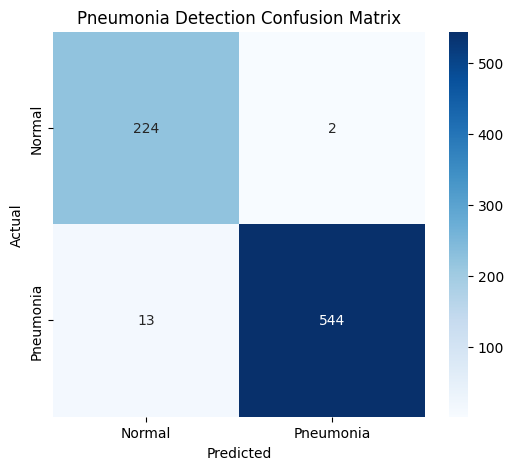


BACTERIAL vs VIRAL CLASSIFICATION
Accuracy  : 0.7774
Precision : 0.7194
Recall    : 0.5405
F1-score  : 0.6173
ROC-AUC   : 0.8404

Bacterial vs Viral Confusion Matrix:
[[333  39]
 [ 85 100]]


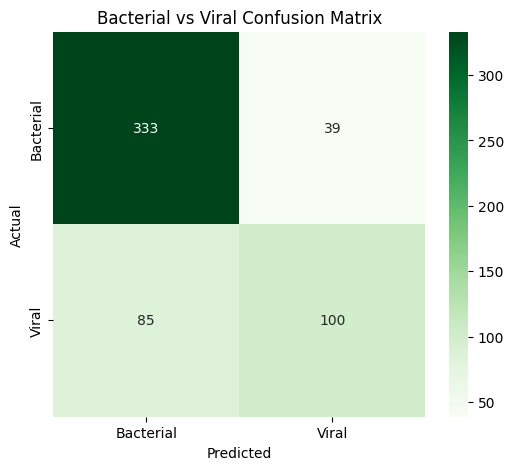


PNEUMONIA CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       226
   Pneumonia       1.00      0.98      0.99       557

    accuracy                           0.98       783
   macro avg       0.97      0.98      0.98       783
weighted avg       0.98      0.98      0.98       783


BACTERIAL vs VIRAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Bacterial       0.80      0.90      0.84       372
       Viral       0.72      0.54      0.62       185

    accuracy                           0.78       557
   macro avg       0.76      0.72      0.73       557
weighted avg       0.77      0.78      0.77       557



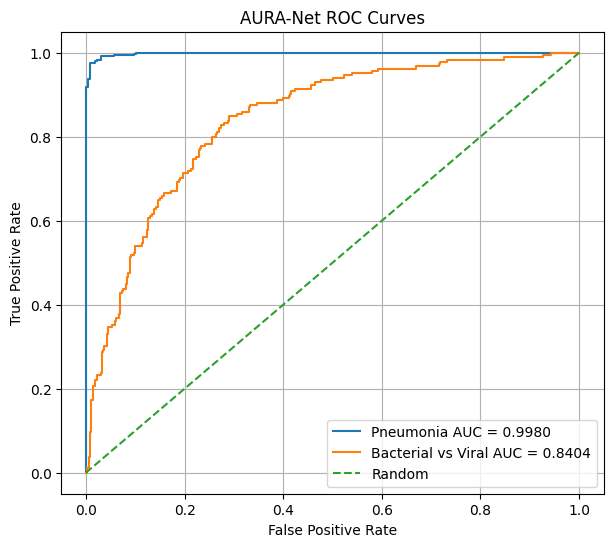


AURA-Net FINAL EVALUATION

Pneumonia Detection:
Accuracy  : 0.9808
Precision : 0.9963
Recall    : 0.9767
F1-score  : 0.9864
ROC-AUC   : 0.9980

Bacterial vs Viral:
Accuracy  : 0.7774
Precision : 0.7194
Recall    : 0.5405
F1-score  : 0.6173
ROC-AUC   : 0.8404


In [19]:
# ============================================================
# AURA-Net Evaluation
# Pneumonia + Bacterial vs Viral
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Evaluation device:", device)


# ============================================================
# 2. RECREATE THE SAME DATASET
# ============================================================

dataset = ChestXrayMultiTaskDataset(
    root_dir="/root/.cache/kagglehub/datasets/nkifor/pneumonia-dataset/versions/1/xraychest"
)

print("Total images:", len(dataset))


# ============================================================
# 3. RECREATE THE SAME 85/15 VALIDATION SPLIT
# ============================================================

train_size = int(0.85 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))


# ============================================================
# 4. VALIDATION DATALOADER
# ============================================================

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# ============================================================
# 5. LOAD AURA-NET
# ============================================================

model = AURANet().to(device)

checkpoint = torch.load(
    "aura_net_best_model.pth",
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    model.load_state_dict(checkpoint)

model.eval()

print("Best AURA-Net model loaded successfully.")


# ============================================================
# 6. COLLECT PREDICTIONS
# ============================================================

pneumonia_true = []
pneumonia_pred = []
pneumonia_prob = []

etiology_true = []
etiology_pred = []
etiology_prob = []


with torch.no_grad():

    for images, labels in val_loader:

        # ----------------------------------------------------
        # Move images to device
        # ----------------------------------------------------

        images = images.to(device)


        # ----------------------------------------------------
        # Get labels
        # ----------------------------------------------------

        pneumonia_labels = labels["pneumonia"].to(device)

        etiology_labels = labels["etiology"].to(device)


        # ----------------------------------------------------
        # MODEL FORWARD PASS
        #
        # AURA-Net returns:
        #
        # {
        #     "pneumonia": tensor,
        #     "etiology": tensor
        # }
        # ----------------------------------------------------

        outputs = model(images)

        pneumonia_output = outputs["pneumonia"]

        etiology_output = outputs["etiology"]


        # ====================================================
        # PNEUMONIA PREDICTION
        # ====================================================

        # Convert pneumonia logit to probability

        pneumonia_probability = torch.sigmoid(
            pneumonia_output
        ).reshape(-1)


        # Probability >= 0.5 = Pneumonia

        pneumonia_prediction = (
            pneumonia_probability >= 0.5
        ).long()


        # Store actual labels

        pneumonia_true.extend(
            pneumonia_labels
            .cpu()
            .numpy()
            .astype(int)
        )


        # Store predictions

        pneumonia_pred.extend(
            pneumonia_prediction
            .cpu()
            .numpy()
            .astype(int)
        )


        # Store probabilities for ROC-AUC

        pneumonia_prob.extend(
            pneumonia_probability
            .cpu()
            .numpy()
        )


        # ====================================================
        # BACTERIAL vs VIRAL
        # ====================================================
        #
        # etiology:
        # 0 = Bacterial
        # 1 = Viral
        # -1 = Normal
        #
        # Normal images are excluded.
        # ====================================================

        valid = etiology_labels >= 0


        if valid.any():

            etiology_logits = etiology_output[valid]

            etiology_labels_valid = (
                etiology_labels[valid]
            )


            # Convert logits to probabilities

            probabilities = torch.softmax(
                etiology_logits,
                dim=1
            )


            # Select class with highest probability

            predictions = torch.argmax(
                probabilities,
                dim=1
            )


            # Store actual labels

            etiology_true.extend(
                etiology_labels_valid
                .cpu()
                .numpy()
                .astype(int)
            )


            # Store predictions

            etiology_pred.extend(
                predictions
                .cpu()
                .numpy()
                .astype(int)
            )


            # Probability of Viral class

            etiology_prob.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
            )


# ============================================================
# 7. CONVERT TO NUMPY ARRAYS
# ============================================================

pneumonia_true = np.array(
    pneumonia_true
)

pneumonia_pred = np.array(
    pneumonia_pred
)

pneumonia_prob = np.array(
    pneumonia_prob
)

etiology_true = np.array(
    etiology_true
)

etiology_pred = np.array(
    etiology_pred
)

etiology_prob = np.array(
    etiology_prob
)


print("\nPrediction collection completed.")

print(
    "Pneumonia samples:",
    len(pneumonia_true)
)

print(
    "Etiology samples:",
    len(etiology_true)
)


# ============================================================
# 8. PNEUMONIA METRICS
# ============================================================

pneumonia_accuracy = accuracy_score(
    pneumonia_true,
    pneumonia_pred
)

pneumonia_precision = precision_score(
    pneumonia_true,
    pneumonia_pred,
    zero_division=0
)

pneumonia_recall = recall_score(
    pneumonia_true,
    pneumonia_pred,
    zero_division=0
)

pneumonia_f1 = f1_score(
    pneumonia_true,
    pneumonia_pred,
    zero_division=0
)

pneumonia_auc = roc_auc_score(
    pneumonia_true,
    pneumonia_prob
)


print("\n" + "=" * 60)

print("PNEUMONIA DETECTION")

print("=" * 60)

print(
    f"Accuracy  : {pneumonia_accuracy:.4f}"
)

print(
    f"Precision : {pneumonia_precision:.4f}"
)

print(
    f"Recall    : {pneumonia_recall:.4f}"
)

print(
    f"F1-score  : {pneumonia_f1:.4f}"
)

print(
    f"ROC-AUC   : {pneumonia_auc:.4f}"
)


# ============================================================
# 9. PNEUMONIA CONFUSION MATRIX
# ============================================================

cm_pneumonia = confusion_matrix(
    pneumonia_true,
    pneumonia_pred
)

print("\nPneumonia Confusion Matrix:")

print(cm_pneumonia)


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm_pneumonia,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Pneumonia"
    ],
    yticklabels=[
        "Normal",
        "Pneumonia"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Pneumonia Detection Confusion Matrix"
)

plt.show()


# ============================================================
# 10. BACTERIAL vs VIRAL METRICS
# ============================================================

etiology_accuracy = accuracy_score(
    etiology_true,
    etiology_pred
)

etiology_precision = precision_score(
    etiology_true,
    etiology_pred,
    zero_division=0
)

etiology_recall = recall_score(
    etiology_true,
    etiology_pred,
    zero_division=0
)

etiology_f1 = f1_score(
    etiology_true,
    etiology_pred,
    zero_division=0
)

etiology_auc = roc_auc_score(
    etiology_true,
    etiology_prob
)


print("\n" + "=" * 60)

print("BACTERIAL vs VIRAL CLASSIFICATION")

print("=" * 60)

print(
    f"Accuracy  : {etiology_accuracy:.4f}"
)

print(
    f"Precision : {etiology_precision:.4f}"
)

print(
    f"Recall    : {etiology_recall:.4f}"
)

print(
    f"F1-score  : {etiology_f1:.4f}"
)

print(
    f"ROC-AUC   : {etiology_auc:.4f}"
)


# ============================================================
# 11. BACTERIAL vs VIRAL CONFUSION MATRIX
# ============================================================

cm_etiology = confusion_matrix(
    etiology_true,
    etiology_pred
)

print(
    "\nBacterial vs Viral Confusion Matrix:"
)

print(cm_etiology)


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm_etiology,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "Bacterial",
        "Viral"
    ],
    yticklabels=[
        "Bacterial",
        "Viral"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Bacterial vs Viral Confusion Matrix"
)

plt.show()


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)

print("PNEUMONIA CLASSIFICATION REPORT")

print("=" * 60)


print(
    classification_report(
        pneumonia_true,
        pneumonia_pred,
        target_names=[
            "Normal",
            "Pneumonia"
        ],
        zero_division=0
    )
)


print("\n" + "=" * 60)

print("BACTERIAL vs VIRAL CLASSIFICATION REPORT")

print("=" * 60)


print(
    classification_report(
        etiology_true,
        etiology_pred,
        target_names=[
            "Bacterial",
            "Viral"
        ],
        zero_division=0
    )
)


# ============================================================
# 13. ROC CURVES
# ============================================================

# Pneumonia ROC

fpr_p, tpr_p, _ = roc_curve(
    pneumonia_true,
    pneumonia_prob
)


# Bacterial vs Viral ROC

fpr_e, tpr_e, _ = roc_curve(
    etiology_true,
    etiology_prob
)


plt.figure(
    figsize=(7, 6)
)


plt.plot(
    fpr_p,
    tpr_p,
    label=(
        f"Pneumonia "
        f"AUC = {pneumonia_auc:.4f}"
    )
)


plt.plot(
    fpr_e,
    tpr_e,
    label=(
        f"Bacterial vs Viral "
        f"AUC = {etiology_auc:.4f}"
    )
)


# Random classifier reference

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "AURA-Net ROC Curves"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)

print("AURA-Net FINAL EVALUATION")

print("=" * 60)


print("\nPneumonia Detection:")

print(
    f"Accuracy  : {pneumonia_accuracy:.4f}"
)

print(
    f"Precision : {pneumonia_precision:.4f}"
)

print(
    f"Recall    : {pneumonia_recall:.4f}"
)

print(
    f"F1-score  : {pneumonia_f1:.4f}"
)

print(
    f"ROC-AUC   : {pneumonia_auc:.4f}"
)


print("\nBacterial vs Viral:")

print(
    f"Accuracy  : {etiology_accuracy:.4f}"
)

print(
    f"Precision : {etiology_precision:.4f}"
)

print(
    f"Recall    : {etiology_recall:.4f}"
)

print(
    f"F1-score  : {etiology_f1:.4f}"
)

print(
    f"ROC-AUC   : {etiology_auc:.4f}"
)